## Myntra Women's Dresses: Pricing & Discount Analysis

I scraped around 3,000 women's dress listings from Myntra every day for 20 days, across three different sort modes: Popularity, Discount, and Recommended. Each sort mode represents a different thing Myntra is trying to surface, and I wanted to see whether that actually shows up in the data.

The dataset ended up with about 54,000 rows and 30 columns covering price, MRP, discount, ratings, inventory, and a few platform-specific fields like promotion tags and delivery promises.

The main thing I was trying to understand is whether the discounting on this platform is genuine or manufactured. At 72% median discount across the entire category, something is clearly off, and I wanted to trace exactly what.

**Dataset:** ~54,000 product snapshots over 20 days, Jan 12 to Jan 31 2026  
**Category:** Women's Dresses  
**Sort modes scraped:** Popularity, Discount, Recommended

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

In [2]:
# load all 20 days across all three sort types
df = pd.concat((pd.read_csv(f) for f in glob("../data/*")), ignore_index=True)

# remove rows where the same product was scraped more than once on the same day
df = df.drop_duplicates(subset=['product_id', 'snapshot_date'], keep='first')

print('Shape: ', df.shape)
print('Source sort distribution:')
print(df['source_sort'].value_counts())


Shape:  (53904, 30)
Source sort distribution:
source_sort
discount       19698
popularity     17830
recommended    16376
Name: count, dtype: int64


#### Data Preparation

Type conversions, derived columns, and a few bucketing decisions.

In [3]:
#convert to datetime format
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])

for col in ["mrp", "price", "discount", "rating", "rating_count"]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

#calc discount % off
df['discount_pct'] = (100*(df['mrp']-df['price'])/df['mrp']).round(2)

#how far current price is from product's all time lowest price
df['price_to_best_gap_pct'] = (100*(df['price']-df['best_price'])/df['price']).round(2)

df['is_available'] = df['available'].astype(str).str.lower().isin(['true', 1, 'yes'])

#create price tier bucket 
df['price_tier'] = pd.cut(df['price'], 
                          bins=[0,500,1000,2000,5000,10000], 
                          labels=['Budget(<500)', 'Low-Mid(500-1k)', 'Mid(1k-2k)', 'Premium(2k-5k)', 'Luxury(5k+)'])

#how many unique days eac product appears in the dataset
df['days_present'] = df.groupby('product_id')['snapshot_date'].transform('nunique')

## continuity cohort: transient products vs stable platform fixtures
df['continuity_cohort'] = pd.cut(
    df['days_present'],
    bins=[0,4,9,14,20],
    labels=['Transient (1-4d)', 'Short (5-9d)', 'Medium (10-14d)', 'Stable (15-20d)'])



### 1. How Deep Are the Discounts?

Before proceeding further I wanted to understand how steep the discounts are.
Typically a median discount of 20–30% would indicate standard promotional activity but the pattern here turned out to be quite different.

In [4]:
#keeping only valid discount rows
df = df[df['discount_pct'].notna()]

print("Prep done. Discount % range:")
print(df['discount_pct'].describe().round(2))

Prep done. Discount % range:
count    53904.00
mean        70.16
std         20.01
min          0.00
25%         60.02
50%         72.02
75%         88.26
max         90.05
Name: discount_pct, dtype: float64


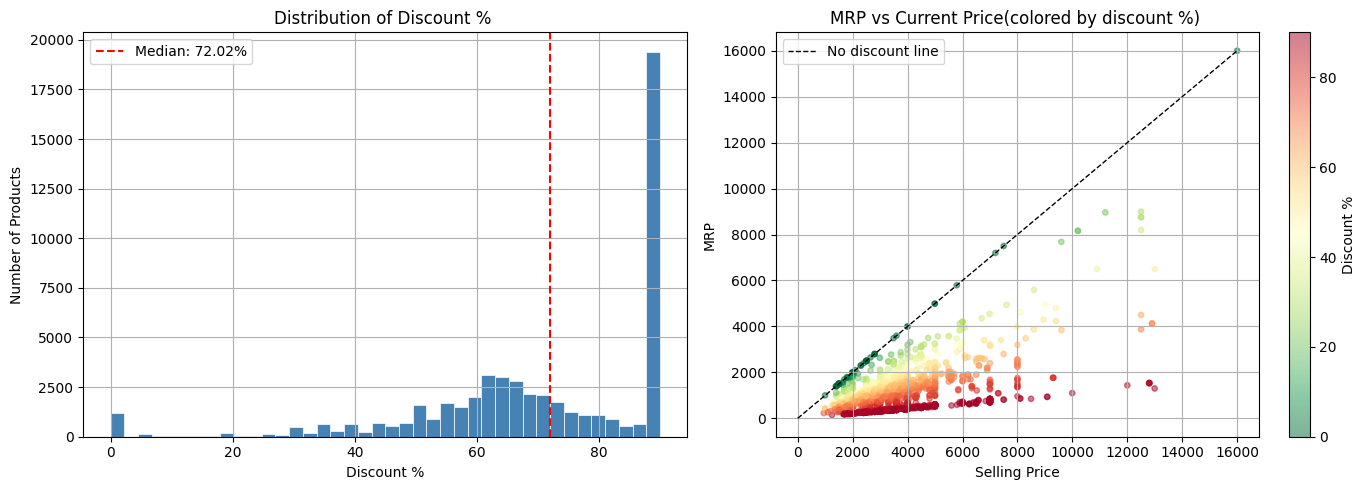

Median discount: 72.02%
Products with >70% discount: 28650 (53.2%)


In [5]:
#plotting histogram and scatter plot
fig, axes = plt.subplots(1,2, figsize=(14,5))

#distribution of discount % usign histogram
axes[0].hist(df['discount_pct'], bins=40, linewidth=0.5, color='steelblue', edgecolor='white')
axes[0].axvline(df['discount_pct'].median(), linestyle='--', color='red',
                label=f'Median: {df['discount_pct'].median()}%')
axes[0].set_title('Distribution of Discount % ')
axes[0].set_xlabel('Discount %')
axes[0].set_ylabel('Number of Products')
axes[0].grid(True)
axes[0].legend()

#MRP vs current price scatter plot(taking sample to avoid overplotting)
sample = df[['mrp', 'price', 'discount_pct']].dropna().sample(2000, random_state=42)
scatter = axes[1].scatter(sample['mrp'], sample['price'], c=sample['discount_pct'], 
                          cmap='RdYlGn_r', s=15, alpha=0.5)
maxval = max(sample['price'].max(), sample['mrp'].max())
axes[1].plot([0, maxval], [0,maxval], 'k--', linewidth=1, label='No discount line')
plt.colorbar(scatter, ax=axes[1], label='Discount %') 
axes[1].set_title('MRP vs Current Price(colored by discount %) ')
axes[1].set_xlabel('Selling Price')
axes[1].set_ylabel('MRP')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

print (f'Median discount: {df['discount_pct'].median()}%')
print (f'Products with >70% discount: {(df['discount_pct']>70).sum()} ({(df['discount_pct']>70).mean()*100:.1f}%)')

Median discount is 72% and over 53% of products are discounted more than 70% off MRP. This does not look like a sale, it looks like the default pricing model for this category. The MRP on most of these listings is not a real price anyone was ever expected to pay.

### 2. Which Brands Actually Discount vs Which Fake It

Not all discounting is the same. Some brands set a genuine high price and run real promotions. Others set an inflated MRP purely to display a large discount number. The positioning map below separates these two groups clearly.

In [6]:
#brands with 100+ appearances
brand_counts = df['brand'].value_counts()
top_brands = brand_counts[brand_counts>=100].index.tolist()
#filtering data for top brands only
df_brands = df[df['brand'].isin(top_brands)].copy()

print('Brands with 100+ appearances: ', len(top_brands))
print('Rows in filtered dataset: ', len(df_brands))

Brands with 100+ appearances:  101
Rows in filtered dataset:  45737


In [7]:
brand_summary = df_brands.groupby('brand').agg(avg_mrp=('mrp', 'mean'),
                                               avg_price=('price', 'mean'),
                                               avg_discount_pct=('discount_pct', 'mean'),
                                               median_discount_pct=('discount_pct', 'median'),
                                               avg_price_to_best_gap=('price_to_best_gap_pct', 'mean'),
                                               avg_rating=('rating', 'mean'),
                                               total_products=('product_id', 'nunique'),
                                               coupon_usage=('coupon_discount', lambda x:x.notna().mean()*100)
                                               ).round(2).reset_index()

brand_summary = brand_summary.sort_values('avg_discount_pct', ascending=False)

print('Top 10 highest discounted brands')
print(brand_summary.head(10)[['brand','avg_mrp','avg_price','avg_discount_pct','avg_rating']])

Top 10 highest discounted brands
                brand  avg_mrp  avg_price  avg_discount_pct  avg_rating
28         FLAMBOYANT  3358.00     347.44             89.67        1.76
23            DRESOUL  9326.85     969.91             89.57        2.34
72           STYLENZA  6999.00     749.74             89.29        0.00
89              VASVI  5032.75     544.36             89.22        2.39
17         Chandbaali  5831.39     635.46             89.09        0.61
61          RAJGRANTH  5136.66     562.49             89.06        3.94
0             Amagyaa  3700.35     409.56             88.97        2.03
64              S.K.C  6999.00     786.21             88.77        0.00
78  Stylecast X Kotty  2991.27     335.61             88.75        3.11
16             Cation  2978.92     333.19             88.73        1.35


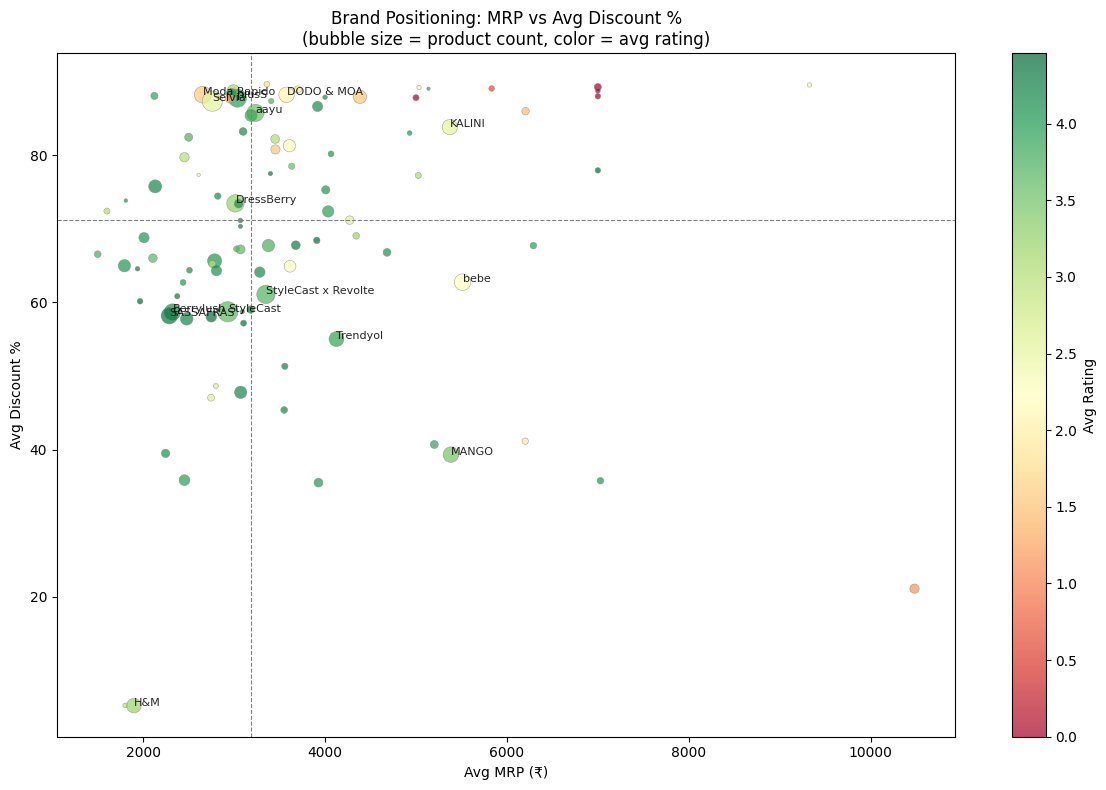

In [8]:
#Brand positioning map : Avg MRP vs Avg Discount %

plt.figure(figsize=(12,8))
scatter = plt.scatter(brand_summary['avg_mrp'], brand_summary['avg_discount_pct'], 
            c=brand_summary['avg_rating'], cmap='RdYlGn', 
            s=brand_summary['total_products'], alpha=0.7,
            linewidth=0.4, edgecolors='grey')

plt.colorbar(scatter, label='Avg Rating')

#label top brands
for _, row in brand_summary.nlargest(15, 'total_products').iterrows():
    plt.annotate(row['brand'], xy=(row['avg_mrp'], row['avg_discount_pct']),
                 fontsize=8, alpha=0.85)
    
#quadrant median lines
plt.axhline(brand_summary['avg_discount_pct'].median(), color='grey', linestyle='--', linewidth=0.8)
plt.axvline(brand_summary['avg_mrp'].median(), color='grey', linestyle='--', linewidth=0.8)

plt.title('Brand Positioning: MRP vs Avg Discount %\n(bubble size = product count, color = avg rating)')
plt.xlabel('Avg MRP (₹)')
plt.ylabel('Avg Discount %')
plt.tight_layout()
plt.show()

Top 10 highest-discount brands average 89% off MRP but ratings between 0 and 3.9. The top cluster in the scatter chart is entirely orange and red bubbles, showing poor ratings regardless of MRP level. These brands set artificially high MRPs so the label shows a huge discount, but the actual transaction price is Rs 350 to Rs 970. H&M sits alone in the bottom-left corner at around 7% discount with honest pricing and strong ratings. MANGO and Biba sit further right with moderate discounts off genuine MRPs. The two pricing philosophies are clearly separated.

### 3. Does Myntra's Sort mode mean anything?
Myntra surfaces products through different sort modes. I wanted to check whether these modes actually differ in the kind of product they show or they are all drawing from the same pool.

/tmp/ipykernel_61862/3244791816.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rated, x='source_sort', y='discount_pct',
/tmp/ipykernel_61862/3244791816.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rated, x='source_sort', y='rating',


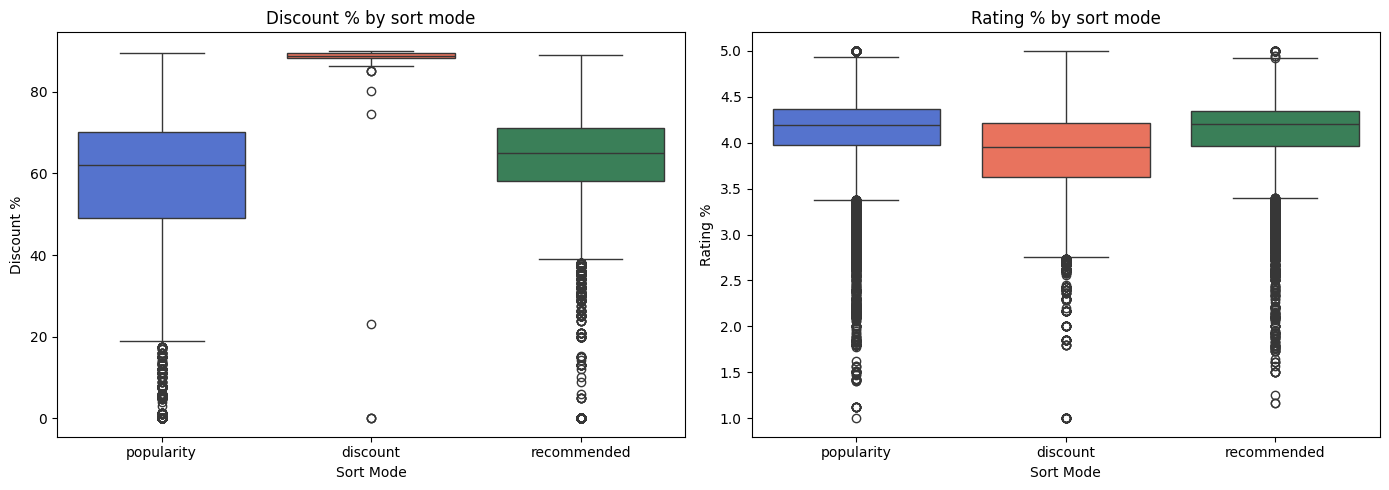

,avg_discount_pct,median_discount_pct,avg_rating,avg_rating_count,avg_mrp,avg_price
source_sort,,,,,,
discount,88.76,88.65,2.25,106.73,3770.77,423.14
popularity,56.43,61.01,3.68,982.86,3890.62,1720.41
recommended,62.74,65.01,3.88,1332.76,2749.57,963.21


In [9]:
import seaborn as sns

sort_order = ['popularity', 'discount', 'recommended']
palette = {'popularity': 'royalblue', 'discount': 'tomato', 'recommended': 'seagreen'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#discount % by sort mode
rated = df[df['rating']>0]
sns.boxplot(data=rated, x='source_sort', y='discount_pct',
            order=sort_order, palette=palette, ax=axes[0])
axes[0].set_title('Discount % by sort mode')
axes[0].set_xlabel('Sort Mode')
axes[0].set_ylabel('Discount %')

#rating by sort mode
sns.boxplot(data=rated, x='source_sort', y='rating',
            order=sort_order, palette=palette, ax=axes[1])
axes[1].set_title('Rating % by sort mode')
axes[1].set_xlabel('Sort Mode')
axes[1].set_ylabel('Rating %')

plt.tight_layout()
plt.show()

#numerical summary
sort_summary = df.groupby('source_sort').agg(avg_discount_pct=('discount_pct', 'mean'),
                                             median_discount_pct=('discount_pct', 'median'),
                                             avg_rating=('rating', 'mean'),
                                             avg_rating_count=('rating_count', 'mean'),
                                             avg_mrp=('mrp', 'mean'),
                                             avg_price=('price', 'mean')).round(2)
                                             
sort_summary

In [10]:
#check brand overlap across sort modes
brands_by_sort_mode = df.groupby('source_sort')['brand'].apply(set)

pop_brands = brands_by_sort_mode.get('popularity', set())
disc_brands = brands_by_sort_mode.get('discount', set())
rec_brands = brands_by_sort_mode.get('recommended', set())

print('Brands in all three sorts: ', (len(pop_brands & disc_brands & rec_brands)))
print('Brands exclusive to Discount: ', (len(disc_brands - pop_brands - rec_brands)))
print('Brands exclusive to Popularity: ', (len(pop_brands - rec_brands - disc_brands)))
print('Brands exclusive to Recommended: ', (len(rec_brands - pop_brands - disc_brands)))


Brands in all three sorts:  42
Brands exclusive to Discount:  70
Brands exclusive to Popularity:  112
Brands exclusive to Recommended:  95


The Discount sort boxplot clearly shows that the Discount sort boxplot have 88-90% with almost no apread.Popularity and Recommended both show wide distributions ranging from around 20% upto 90%.
Thr rating boxplot shows that the Discount sort median is lower than the other two, with a longer tail reaching down toward 1.

The numerical summary also tells that Discount sort avg rating count is 107 vs Popularity which is 983. That's approx. 10x fewer reviews, meaning Discount sort porducts are mostly low volume,low engagement products. Also, there are 70 brands that are exclusive to Discount sort (never in other two sorts)suggesting they have no organic platform presence and exist only as MRP inflation vehicles.

### 4. Statistical Validation: Are Sort Mode differences real?
The boxplot suggested Discount sort products are rated lower. Before treating that as a real finding I wanted to test whether the differnce is statistically meaningful or just sampling variation.

In [11]:
from scipy import stats

rated = df[df['rating']>0].copy()

groups = {sort: rated[rated['source_sort']==sort]['rating'].dropna().values
          for sort in ['popularity', 'discount', 'recommended']}

print ("Sample sizes(rated products only):")
for k, v in groups.items():
    print(f" {k}: {len(v):,} rows, mean rating: {v.mean():.3f}")

#KChecking significance via kruskal wallis test
stat, p = stats.kruskal(*groups.values())
print("\nKruskal Wallist Test")
print (f"H-stat value {stat:.4f}")
print (f"p value {p:.4f}")
print(f'Result: {'Significant difference exists (p<0.05)' if p<0.05 else 'No significant difference found'}')


Sample sizes(rated products only):
 popularity: 16,036 rows, mean rating: 4.097
 discount: 11,405 rows, mean rating: 3.879
 recommended: 15,499 rows, mean rating: 4.104

Kruskal Wallist Test
H-stat value 2692.4632
p value 0.0000
Result: Significant difference exists (p<0.05)


In [12]:
#Pairwise Mann Whitney test with bonferroni correction
from itertools import combinations

bonferroni_threshold = 0.05/3
print(f"Adjusted significance threhold: {bonferroni_threshold:.4f}")

for a, b in combinations(groups.keys(), 2):
    ustat, p = stats.mannwhitneyu(groups[a], groups[b], alternative='two-sided')
    n1, n2 = len(groups[a]), len(groups[b])

    effect_size = abs(1- (2*ustat)/(n1*n2))
    magnitude = 'Large' if effect_size >0.3 else 'Medium' if effect_size > 0.1 else 'Small'
    sig = 'Significant' if p<0.05 else 'Not Significant'
    print(f'{a} vs {b}: p={p:.5f} | {sig} | effect_size={effect_size:.4f}({magnitude})')



Adjusted significance threhold: 0.0167
popularity vs discount: p=0.00000 | Significant | effect_size=0.3222(Large)
popularity vs recommended: p=0.92399 | Not Significant | effect_size=0.0006(Small)
discount vs recommended: p=0.00000 | Significant | effect_size=0.3327(Large)


                 mean       sem      ci95
source_sort                              
popularity   4.096641  0.003530  0.006919
discount     3.879422  0.004472  0.008766
recommended  4.104356  0.003270  0.006409


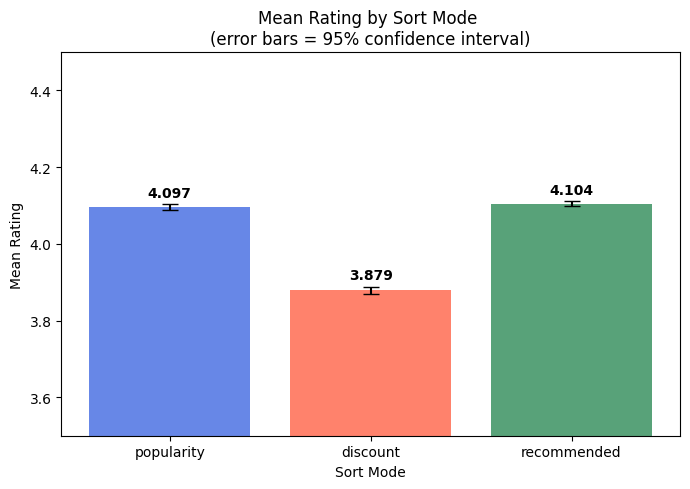

In [13]:
#visualise mean rating + 95% Ci by sort mode
means = (rated.groupby('source_sort')['rating']
         .agg(['mean', 'sem'])
        .reindex(['popularity', 'discount', 'recommended']))
means['ci95'] = means['sem']*1.96
colors_list = [palette[s] for s in means.index]
print(means)

fig, ax = plt.subplots(figsize=(7,5))
ax.bar(means.index, means['mean'], yerr=means['ci95'],
       color=colors_list, capsize=6, alpha=0.8)
ax.set_ylim(3.5,4.5)
ax.set_title('Mean Rating by Sort Mode \n(error bars = 95% confidence interval)')
ax.set_ylabel('Mean Rating')
ax.set_xlabel('Sort Mode')

for i, (idx,row) in enumerate(means.iterrows()):
    ax.text(i, row['mean']+row['ci95']+0.02, f"{row['mean']:.3f}",
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Discount sort is significantly different from both Popularity and Recommended (p close to 0, effect size 0.32–0.33). Popularity and Recommended are not significantly different from each other (p = 0.92). 

The confidence interval chart further proves this as the Discount bar(3.879) sits clearly below the other two (4.097, 4.104) with no overlap in the error bars. The difference is real, not noise.

### 5. Product survival & Sell through
to check if high discounts actually move inventory? The obvious assumption is that deep discounts drive sales. I have inventory snapshots across 20 days so I tested whether the products that were discounted higher actually depleted faster.

In [14]:
#continuity cohort summary
cohort_summary = df.groupby('continuity_cohort', observed=True).agg(unique_products=('product_id', 'nunique'),
                                                                    avg_discount_pct=('discount_pct', 'mean'),
                                                                    rated_pct=('rating_count', lambda x: (x>0).mean()*100)).round(2)

print("Continuity cohorts: ")

cohort_summary

Continuity cohorts: 


,unique_products,avg_discount_pct,rated_pct
continuity_cohort,,,
Transient (1-4d),2541,65.87,76.44
Short (5-9d),1407,67.07,80.17
Medium (10-14d),924,69.43,83.20
Stable (15-20d),1533,72.31,78.74


Stable products (15 to 20 days) carry a higher avg discount(72.3%) than transient products(65.9%)suggesting that items with deep discounts are not being pulled after failing to
sell. They sit on the platform permanently at their inflated-MRP discount. This is the opposite of what onw would expect if heavy discounts were clearly stock.

In [15]:
#stable vs transient rating comparison
rated = df[df['rating']>0]
stable = rated[rated['continuity_cohort']=='Stable (15-20d)']
transient = rated[rated['continuity_cohort']=='Transient (1-4d)']

#wighted avg rating (so that products with more reviews matter more)
def weighted_avg(group):
     g = group[group['rating_count']>0]
     return np.average(g['rating'], weights=g['rating_count']) if len(g)>0 else np.nan

w_stable = weighted_avg(stable)
w_transient = weighted_avg(transient)

#cohen's d for effect size
def cohens_d(a,b):
    a, b = np.array(a, dtype=float), np.array(b, dtype=float)
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    n1, n2 = len(a), len(b)
    s = np.sqrt(((n1-1)*np.var(a,ddof=1) + (n2-1)*np.var(b,ddof=1))/(n1+n2-2))
    return (np.mean(a) - np.mean(b)) / s if s > 0 else np.nan

#bootstrap 95%CI on mean difference
def bootstrap_mean_diff(a, b, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    a, b = np.array(a, dtype=float), np.array(b, dtype=float)
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    diffs = [np.mean(rng.choice(a, len(a), replace=True)) - np.mean(rng.choice(b, len(b), replace=True)) 
             for _ in range(n_boot)]  
    return np.mean(diffs), np.percentile(diffs, 2.5), np.percentile(diffs, 97.5)


d = cohens_d(stable['rating'], transient['rating'])
_, pval = stats.mannwhitneyu(stable['rating'], transient['rating'], alternative='two-sided')
mean_diff, ci_lo, ci_hi = bootstrap_mean_diff(stable['rating'], transient['rating'])

print("Stable vs Transient products: ")
print(f'Stable  n={stable['product_id'].nunique():,}, avg rating: {stable['rating'].mean():.3f}, weighted: {w_stable:.3f}')
print(f'Transient  n={transient['product_id'].nunique():,}, avg rating: {transient['rating'].mean():.3f}, weighted: {w_transient:.3f}')

print(f"\nMann Whiteney p value: {pval:.2e}")
print(f"Cohen's d: {d:.3f} (small effect)")
print(f"Bootstrap 95% CI on mean diff: [{ci_lo:.3f}, {ci_hi:.3f}]")

Stable vs Transient products: 
Stable  n=1,218, avg rating: 4.058, weighted: 4.262
Transient  n=1,975, avg rating: 4.006, weighted: 4.228

Mann Whiteney p value: 1.87e-07
Cohen's d: 0.117 (small effect)
Bootstrap 95% CI on mean diff: [0.036, 0.069]


In [16]:
#stable vs transient inside each discount bucket
#questions does stable advantage hold across all discount levels, or only at certain depths?
discount_bins   = [0, 40, 60, 75, 100]
discount_labels = ['<40%', '40-60%', '60-75%', '75%+']

rated['disc_bucket'] = pd.cut(rated['discount_pct'], bins=discount_bins, labels=discount_labels, include_lowest=True)

pivot = (rated[rated['continuity_cohort'].isin(['Transient (1-4d)', 'Stable (15-20d)'])]
         .groupby(['disc_bucket', 'continuity_cohort'], observed=True)
         .agg(unique_products=('product_id', 'nunique'),
              avg_rating=('rating', 'mean')))

print(" Avg Rating: Stable vs Transient by Discount Bucket ")
pivot['avg_rating'].unstack('continuity_cohort')


 Avg Rating: Stable vs Transient by Discount Bucket 


continuity_cohort,Transient (1-4d),Stable (15-20d)
disc_bucket,,
<40%,4.192257,4.183123
40-60%,4.042212,4.151782
60-75%,4.015819,4.099581
75%+,3.917766,3.955603


Stable products rate higher than transient ones (Cohen's d = 0.117, p < 0.001, 95% CI entirely positive [0.036, 0.069]). 
The effect is small but consistent across repeated sampling, suggesting quality products earn longer platform presence.

The gap is most visible in the 40–75% discount range.At 75%+ both cohorts drop equally suggesting extreme discounts erode customer trust regardless of how long the product has been listed.

In [17]:
#inventory depletion: does high discount actually drive sell through?
df_sorted = df.sort_values(['product_id', 'snapshot_date'])

prod_df = df_sorted.groupby('product_id').agg(
    first_inventory=('inventory', 'first'),
    last_inventory=('inventory', 'last'),
    max_inventory=('inventory', 'max'),
    avg_discount=('discount_pct', 'mean'),
    avg_rating=('rating', 'mean'),
    days_present=('days_present', 'max')).reset_index()

prod_df['depletion'] = (prod_df['first_inventory']- prod_df['last_inventory']).clip(lower=0)
prod_df['depletion_rate'] = prod_df['depletion']/ prod_df['first_inventory']
prod_df['restock_flag'] = (prod_df['max_inventory']> prod_df['first_inventory'])
prod_df['sold_anything'] = (prod_df['depletion'] > 0).astype(int)

prod_df['disc_bucket'] = pd.cut(prod_df['avg_discount'], bins=[0, 40, 60, 75, 100],labels=['<40%', '40-60%', '60-75%', '75%+'])

print(f"Products tracked: {len(prod_df):,}")
print(f"Products that sold at least one unit: {prod_df['sold_anything'].mean()*100:.1f}%")
print(f"Products that were restocked: {prod_df['restock_flag'].mean()*100:.1f}%")


Products tracked: 6,405
Products that sold at least one unit: 41.7%
Products that were restocked: 38.1%


Sell Through Rate by Discount Bucket 
             products  sell_thorugh_rate_pct  avg_depletion_rate  median_first_inventory
disc_bucket                                                                             
<40%              414                 50.242               0.163                    21.0
40-60%           1169                 44.654               0.179                    27.0
60-75%           2150                 44.093               0.169                    32.0
75%+             2540                 36.614               0.121                    14.0


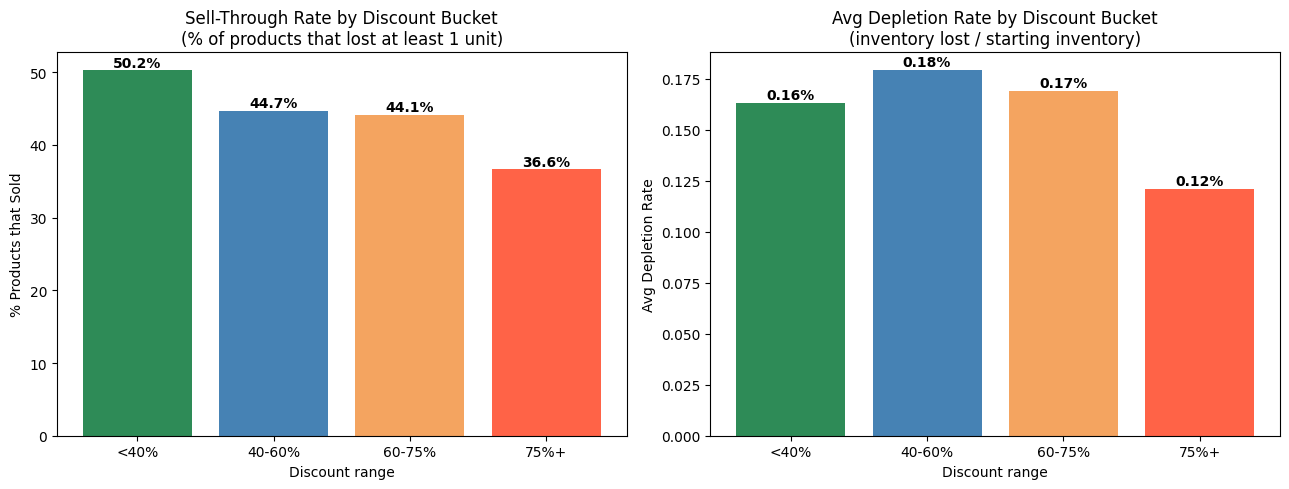

In [18]:
sell_through = prod_df.groupby('disc_bucket', observed=True).agg(products=('product_id', 'count'),
                                                                     sell_thorugh_rate_pct=('sold_anything', lambda x:x.mean()*100),
                                                                     avg_depletion_rate=('depletion_rate', 'mean'),
                                                                     median_first_inventory=('first_inventory', 'median')).round(3)

print("Sell Through Rate by Discount Bucket ")
print(sell_through.to_string())

#plotting bar chart of discount bucket
fig, axes = plt.subplots(1,2, figsize=(13,5))


bar_colors = ['seagreen', 'steelblue', 'sandybrown', 'tomato']

#sell through rate by discount bucket
axes[0].bar(sell_through.index, sell_through['sell_thorugh_rate_pct'], color=bar_colors)
axes[0].set_title('Sell-Through Rate by Discount Bucket\n(% of products that lost at least 1 unit)')
axes[0].set_xlabel('Discount range')
axes[0].set_ylabel('% Products that Sold')
for i, v in enumerate(sell_through['sell_thorugh_rate_pct']):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

#avg depltion rate by discount bucket
axes[1].bar(sell_through.index, sell_through['avg_depletion_rate'], color=bar_colors)
axes[1].set_title('Avg Depletion Rate by Discount Bucket\n(inventory lost / starting inventory)')
axes[1].set_xlabel('Discount range')
axes[1].set_ylabel('Avg Depletion Rate')
for i, v in enumerate(sell_through['avg_depletion_rate']):
    axes[1].text(i, v+0.002, f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Counter-intuitive finding:** products with 75%+ or more discounts have the lowest sell-through rate at 36.6% and the lowest depletion rate 0.12.
The 40 to 60% discount bucket actually depletes the most inventory on average at 0.18. Higher discounts are not driving more sales.
These high discount products also have the lowest median starting inventory at 14 units compared to 21 to 32 units for other buckets, suggesting they are low volume, low demand products that were assignes a high discount from day one rather than gradually discounted to clear stock.

### 6. Brand Clustering
Instead of manually categorising brands, I let K-Means find the natural groupings using pricing, discount depth, ratings, rating volume, and promotion behavious. Tested K from 2 to 8 using silhoutte scores and chose K=4 since it gave the most interpretable groups without over splitting the brand dataset.

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = df[df['brand'].isin(top_brands)].groupby('brand').agg(
    avg_mrp=('mrp', 'mean'),
    avg_discount_pct=('discount_pct', 'mean'),
    avg_rating=('rating', lambda x: x[x > 0].mean()),
    avg_rating_count=('rating_count', 'mean'),
    coupon_usage=('coupon_discount', lambda x: x.notna().mean() * 100),
    price_to_best_gap=('price_to_best_gap_pct', 'mean'),
    promotion_rate=('has_promotion', lambda x: x.astype(str).str.lower().isin(['true','1','yes']).mean() * 100)
).dropna().reset_index()

feature_cols = cluster_features.select_dtypes(include='float64').columns

X = cluster_features[feature_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Brands going into clustering: ', len(cluster_features))


Brands going into clustering:  96


In [20]:
optimal_K = 4
km_final = KMeans(n_clusters=optimal_K, random_state=42, n_init=10)
cluster_features['cluster'] = km_final.fit_predict(X_scaled)

cluster_profile = cluster_features.groupby('cluster')[feature_cols].mean().round(2)
cluster_profile['brand_count'] = cluster_features.groupby('cluster')['brand'].count()

print("Cluster Profiles ")
print(cluster_profile.to_string())

Cluster Profiles 
         avg_mrp  avg_discount_pct  avg_rating  avg_rating_count  coupon_usage  price_to_best_gap  promotion_rate  brand_count
cluster                                                                                                                       
0        3638.12             81.12        3.91            382.92        100.00              33.20           36.07           43
1        2969.24             75.57        4.04            404.04         99.39              32.63           59.18            5
2        2890.60             64.80        4.19           1688.62        100.00              30.37           86.78           33
3        4960.17             41.33        4.15            166.93        100.00              17.91           62.04           15


In [25]:
#cluster names based ont he profile output above

cluster_names ={
    0: 'Fake-MRP Discount-First Brands',
    1: 'Mid Tier Platform Brands',
    2: 'High-Volume Platform Brands',
    3: 'Genuine Premium & International'
}
cluster_color_map = {
    'High-Volume Platform Brands': 'royalblue',
    'Fake-MRP Discount-First Brands': 'tomato',
    'Genuine Premium & International': 'seagreen',
    'Mid Tier Platform Brands': 'purple'
}

cluster_features['cluster_name'] = cluster_features['cluster'].map(cluster_names)

print("Top 15 Brands per Cluster: ")
for i, name in cluster_names.items():
    brands_in = cluster_features[cluster_features['cluster']==i]['brand'].tolist()
    print(f'\n{name} ({len(brands_in)}) brands: ')
    print(', '.join(sorted(brands_in)[:15]) )

Top 15 Brands per Cluster: 

Fake-MRP Discount-First Brands (43) brands: 
Amagyaa, Anouk, Attire Empire, Azira, BAESD, CORSICA, Cation, Chandbaali, DAEVISH, DODO & MOA, DRESOUL, DressBerry Curve, FLAMBOYANT, HERE&NOW, HOUSE OF MIRA

Mid Tier Platform Brands (5) brands: 
DressBerry, EVERYDAY by ANI, STREET 9, Selvia, Stylecast X Slyck

High-Volume Platform Brands (33) brands: 
Antheaa, Athena, Athena Immutable, Berrylush, Berrylush Curve, Boho By Athena, CURVY STREET, Chemistry, Claura, DRAPE AND DAZZLE, Globus, Janasya, Libas, Nayo, Pink Paprika by SASSAFRAS

Genuine Premium & International (15) brands: 
Babli, Biba, FableStreet, Forever New, H&M, Inddus, JC Collection, MADHURAM, MANGO, Miss Chase, NEXT, Styli, Trendyol, Vero Moda, bebe


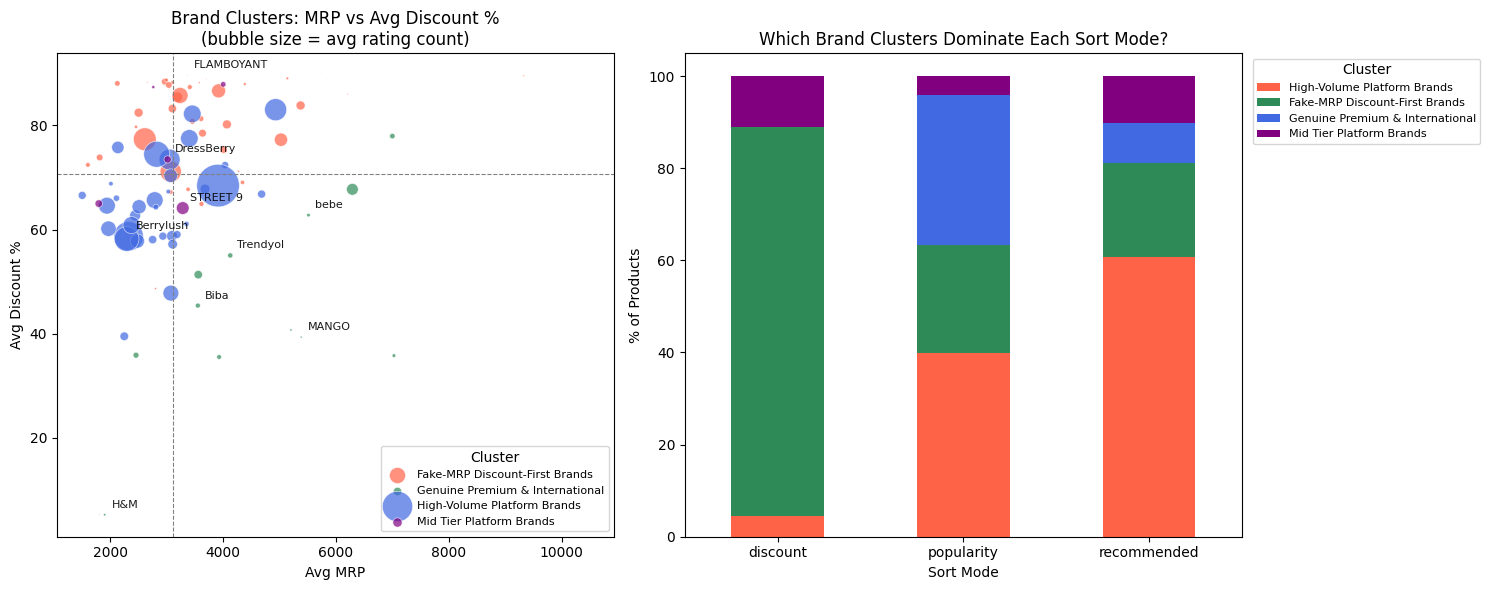

Cluster share by sort mde(in %):
cluster_name  Fake-MRP Discount-First Brands  Genuine Premium & International  High-Volume Platform Brands  Mid Tier Platform Brands
source_sort                                                                                                                         
discount                                84.5                              0.1                          4.4                      11.0
popularity                              23.5                             32.5                         39.9                       4.1
recommended                             20.4                              8.6                         60.8                      10.3


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# left: cluster scatter (MRP vs Discount %, bubble = rating count)
for name, group in cluster_features.groupby('cluster_name'):
    axes[0].scatter(
        group['avg_mrp'], group['avg_discount_pct'], 
        s=group['avg_rating_count']*0.08,
        color=cluster_color_map[name], 
        label=name, alpha=0.7, edgecolors='white', linewidth=0.5)
    
notable_brands = ['H&M', 'MANGO', 'bebe', 'DressBerry', 'Berrylush', 'STREET 9', 'Biba', 'FLAMBOYANT', 'Trendyol']
for _, row in cluster_features[cluster_features['brand'].isin(notable_brands)].iterrows():
    axes[0].annotate(row['brand'], (row['avg_mrp'], row['avg_discount_pct']), 
                     fontsize=8, alpha=0.9, xytext=(5,5), textcoords='offset points')

axes[0].axhline(cluster_features['avg_discount_pct'].median(), linestyle='--', linewidth=0.8, color='grey')
axes[0].axvline(cluster_features['avg_mrp'].median(), linestyle='--', linewidth=0.8, color='grey')
axes[0].set_title('Brand Clusters: MRP vs Avg Discount %\n(bubble size = avg rating count)')
axes[0].set_xlabel('Avg MRP')
axes[0].set_ylabel('Avg Discount %')
axes[0].legend(title='Cluster', fontsize=8)

# right: which clusters dominate each sort mode?
if 'cluster_name' in df.columns:
    df = df.drop(columns=['cluster_name'])
df = df.merge(cluster_features[['brand', 'cluster_name']], on='brand', how='left')

sort_cluster = df.groupby(['source_sort', 'cluster_name']).size().unstack(fill_value=0)
sort_cluster_pct = sort_cluster.div(sort_cluster.sum(axis=1), axis=0)*100
col_order        = [c for c in cluster_color_map if c in sort_cluster_pct.columns]

sort_cluster_pct[col_order].plot(kind='bar',
                       stacked=True, ax=axes[1], color=[cluster_color_map[c] for c in sort_cluster_pct.columns])

axes[1].set_title('Which Brand Clusters Dominate Each Sort Mode?')
axes[1].set_xlabel('Sort Mode')
axes[1].set_ylabel('% of Products')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

print('Cluster share by sort mde(in %):')
print(sort_cluster_pct.round(1).to_string())

The Discount sort is 85% dominated by the Fake MRP cluster.Popularity and Recommended are split between genuine platform brands and high volume premium brands. 

This confirms sort mode is a real business signal and Myntra's Discount sort is effectively a low-quality clearance rack, distinctly separated from other sorts.

### 7. Price Volatitlity Index
to check which brands manage their pricing vs which just set and forget.
Having 20 days of price data means I can meansure whether a brands' prices actually move. I used coefficient of variation of price per product as the measure, then aggreagated to brand level.

In [27]:
#product level price stability(will take into account only products with 3+ appearances )
product_price_stats = df.groupby('product_id').agg(
    price_mean=('price', 'mean'),
    price_std=('price', 'std'),
    price_min=('price', 'min'),
    price_max=('price', 'max'),
    days_appeared=('snapshot_date', 'nunique'),
    brand=('brand', 'first')).reset_index()

product_price_stats = product_price_stats[product_price_stats['days_appeared']>=3].copy()
product_price_stats['price_cv'] = (product_price_stats['price_std']/product_price_stats['price_mean'] *100).round(3)

product_price_stats['price_range_pct'] = (100*(product_price_stats['price_max']-product_price_stats['price_min'])
                                          /product_price_stats['price_mean']).round(3)

print(f'Total Products tracked: {len(product_price_stats):,}')
print(f'Porducts with zero price movement: {(product_price_stats['price_cv']==0).sum():,} {(product_price_stats['price_cv']==0).mean()*100:.1f}%')

Total Products tracked: 4,767
Porducts with zero price movement: 2,277 47.8%


In [28]:
# brand-level volatility index
brand_volatility = (
    product_price_stats[product_price_stats['brand'].isin(top_brands)]
    .groupby('brand')
    .agg(avg_price_cv=('price_cv', 'mean'),
         pct_products_repriced=('price_cv', lambda x: (x>0.5).mean()*100),
         products_tracked=('product_id', 'count')
    ).round(3).reset_index().sort_values('avg_price_cv', ascending=False)
)

zero_cv = brand_volatility[brand_volatility['avg_price_cv']==0].sort_values('products_tracked', ascending=False)

print(" Top 15 Most Volatile brands: ")
print(brand_volatility[:15].to_string())
print('\nBrands with Zero Price movement: ')
print(zero_cv.to_string())

 Top 15 Most Volatile brands: 
               brand  avg_price_cv  pct_products_repriced  products_tracked
26   EVERYDAY by ANI        11.156                  9.091                11
15      CURVY STREET         9.999                 90.000                10
71          STREET 9         9.880                 75.610                41
66  SASSAFRAS BASICS         9.001                100.000                15
65         SASSAFRAS         9.000                 90.179               112
99          glitchez         8.848                 86.207                29
81            Stylum         8.761                 95.238                21
57        Phosphorus         8.406                 95.455                22
74           Sangria         8.324                 82.857                35
18         Chemistry         8.162                 87.234                47
52              NEXT         8.152                 93.750                16
9          Berrylush         8.068                 90.000

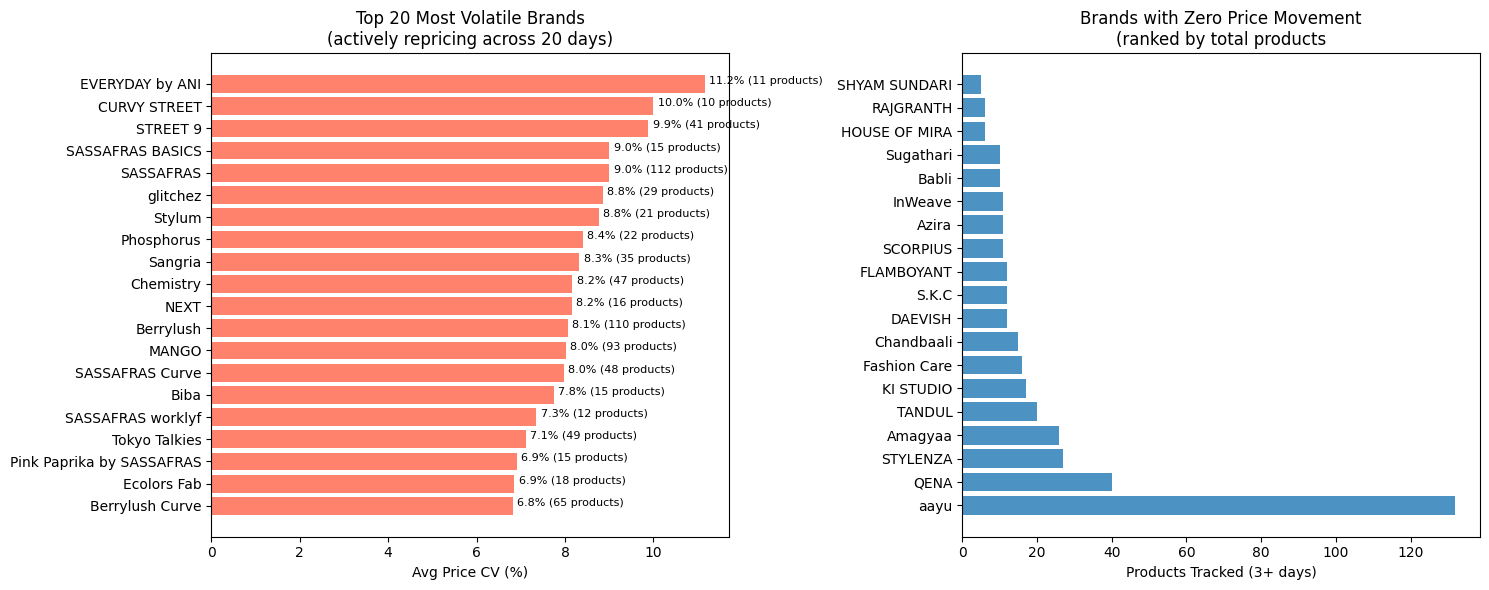

In [29]:
fig, axes = plt.subplots(1,2, figsize=(15,6))

#top volatile brands
top_volatile = brand_volatility.head(20)
axes[0].barh(top_volatile['brand'], top_volatile['avg_price_cv'], color='tomato', alpha=0.8)
axes[0].set_title('Top 20 Most Volatile Brands\n(actively repricing across 20 days)')
axes[0].set_xlabel('Avg Price CV (%)')
axes[0].invert_yaxis()
for i, (_,row) in enumerate(top_volatile.iterrows()):
    axes[0].annotate(
        f"{row['avg_price_cv']:.1f}% ({int(row['products_tracked'])} products)",
        xy=(row['avg_price_cv'], i),         
        xytext=(row['avg_price_cv'] + 0.1, i),
        fontsize=8
    )

#zero volatility brands ranked by products tracked
axes[1].barh(zero_cv['brand'], zero_cv['products_tracked'], alpha=0.8)
axes[1].set_title('Brands with Zero Price Movement\n(ranked by total products')
axes[1].set_xlabel('Products Tracked (3+ days)')

plt.tight_layout()
plt.show()

In [30]:
volatility_cluster = brand_volatility.merge(
    cluster_features[['brand', 'cluster_name', 'avg_discount_pct', 'avg_rating']],
    on='brand', how='inner')

corr1, p1 = stats.spearmanr(volatility_cluster['avg_price_cv'], volatility_cluster['avg_discount_pct'])
corr2, p2 = stats.spearmanr(volatility_cluster['avg_price_cv'], volatility_cluster['avg_rating'])

print(f"Spearman: Price Volatility vs  Avg Discount \nr={corr1:.4f}, p={p1:.4f}")
print(f"  {'Significant' if p1 < 0.05 else 'Not significant'} | ")
    #  f"{'more discount = less repricing' if corr1 < 0 else 'more discount = more repricing'}")

print(f"\nSpearman: Price Volatility vs  Avg Rating \nr={corr2:.4f}, p={p2:.4f}")
print(f"  {'Significant' if p2 < 0.05 else 'Not significant'}")


Spearman: Price Volatility vs  Avg Discount 
r=-0.4351, p=0.0000
  Significant | 

Spearman: Price Volatility vs  Avg Rating 
r=0.1826, p=0.0749
  Not significant


Two distinct pricing personalities emerge here. Active pricers (SASSAFRAS at 90% of products
repriced, Berrylush at 90%, MANGO at 78%) are doing genuine revenue management.

Static pricers like aayu(132 products,CV=0 across all of them) and  QENA(40 products,zero movement) have set a price and never changed it.

The Spearman correlation r=−0.44(p<0.001) confirms this is systematic. Brands with higher discounts are significantly less likely to reprice. The brands doing the price changes like SASSAFRAS, MANGO, Berrylush are also the brands with moderate, honest discounts.
Fake MRP brands set their inflated discount once and leave it there permanently.

### 8. What actually drives a Products's Rating?
Throughout the analysis I looked at individual relationships between pricing and rating. Here I wanted to put everything togehter in one model and see which variables the data finds most predictive. I use Random Forest rather than linear regression because the relationships here are unlikely to be linear, and the main output I cared about was feature importance, not prediction accuracy.

In [32]:
from sklearn.ensemble import  RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# one row per unique product, averaged across appearances
model_df = df[df['rating'] > 0].groupby('product_id').agg(
    rating=('rating', 'mean'),
    discount_pct=('discount_pct', 'mean'),
    mrp=('mrp', 'mean'),
    price=('price', 'mean'),
    inventory=('inventory', 'mean'),
    has_promotion=('has_promotion', lambda x: x.astype(str).str.lower().isin(['true','1','yes']).mean()),
    is_fast_fashion=('is_fast_fashion', 'first'),
    source_sort=('source_sort', lambda x: x.mode()[0]),
    price_to_best_gap=('price_to_best_gap_pct', 'mean')
).reset_index().dropna()

model_df['source_sort_enc']     = model_df['source_sort'].map({'popularity': 0, 'discount': 1, 'recommended': 2})
model_df['is_fast_fashion_enc'] = model_df['is_fast_fashion'].astype(int)

feature_cols_model = ['discount_pct', 'mrp', 'price', 'inventory',
                      'has_promotion', 'is_fast_fashion_enc', 'source_sort_enc', 'price_to_best_gap']
feature_labels     = ['Discount %', 'MRP', 'Selling Price', 'Inventory',
                      'Has Promotion', 'Is Fast Fashion', 'Source Sort', 'Price-to-Best Gap']

X_model = model_df[feature_cols_model]
y_model = model_df['rating']
Xtrain, Xtest, ytrain, ytest = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(Xtrain, ytrain)
ypred = rf.predict(Xtest)

r2 = r2_score(ytest, ypred)
mae = mean_absolute_error(ytest, ypred)

print(f'R²:  {r2:.4f} ; pricing feature alone explains {r2*100:.1f} of rating variance')
print(f'MAE: {mae:.4f}')

R²:  0.1844 ; pricing feature alone explains 18.4 of rating variance
MAE: 0.3043


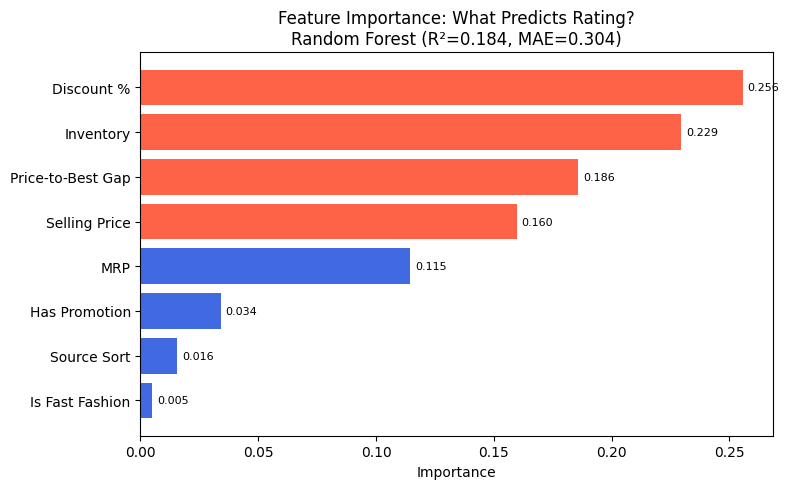

In [33]:
importance_df = pd.DataFrame({
    'feature': feature_labels,
    'importance': rf.feature_importances_
}).sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['tomato' if i>importance_df['importance'].median() else 'royalblue' for i in importance_df['importance']]
ax.barh(importance_df['feature'], importance_df['importance'], color=colors)
ax.set_title(f'Feature Importance: What Predicts Rating?\nRandom Forest (R²={r2:.3f}, MAE={mae:.3f})')
ax.set_xlabel('Importance')

for i, (_, row) in enumerate(importance_df.iterrows()):
    ax.annotate(f'{row['importance']:.3f}', xy=(row['importance'], i), 
                xytext=(row['importance']+0.002, i), fontsize=8, va='center')
plt.tight_layout()
plt.show()

R² = 0.185, meaning pricing features explain 18.5% of rating variance. The low R² is expected
and is itself a findin.It cannot be predicted whether a product is good from its price, discount, or inventory level alone. Ratings are also shaped by things the data does not capture like product photos,quality, delivery experience etc

Discount % and Inventory are the top two features, not because high discount causes high ratings but because both correlate with brand type. Fake MRP brands have extreme discounts, low inventory and poor ratings. Source Sort and Fast Fashion flag are near zero. Myntra's categorisation labels carry almost no predictive signal once pricing is already in the model.